# Use case — deduplicating an embedding corpus

A content feed dominated by **reposts**: news syndication, mirrored product listings, template
emails, cached responses. Most items are near-duplicates of a few hundred originals. Before you index
them for RAG or train on them, you want to **collapse each duplicate cluster to one representative** —
at bounded memory, in one `O(N)` pass, with no pairwise `O(N²)` similarity matrix.

`betula-cluster` does this directly: cluster by *direction* (`normalize=True`), then
`find_near_duplicates` returns the rows that fall into the same tight microcluster.

```bash
pip install betula-cluster matplotlib seaborn pandas scikit-learn
```

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA

from betula_cluster import Betula

sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})
rng = np.random.default_rng(0)

## A repost-heavy embedding corpus

`N_CANON` original documents, each a *direction* in 32-D (in high dimensions distinct documents are
near-orthogonal, cosine ≈ 0). Each original is reposted 20–50 times as a near-duplicate: same
direction perturbed by tiny noise (cosine ≈ 0.9999), with its own magnitude. We keep each row's true
source id to score the dedup.

In [2]:
DIM, N_CANON = 32, 200
canon = rng.standard_normal((N_CANON, DIM))
canon /= np.linalg.norm(canon, axis=1, keepdims=True)

rows, source = [], []
for i in range(N_CANON):
    for _ in range(int(rng.integers(20, 50))):  # reposts of original i
        direction = canon[i] + 0.01 * rng.standard_normal(DIM)  # ~same direction
        rows.append(rng.lognormal(0.0, 0.4) * direction)  # its own magnitude
        source.append(i)
X = np.vstack(rows).astype(np.float64)
source = np.array(source)
perm = rng.permutation(len(X))  # shuffle so reposts aren't adjacent
X, source = X[perm], source[perm]
n_copies = len(X) - N_CANON  # all but one per original are redundant
print(f"corpus: {len(X)} rows = {N_CANON} originals + {n_copies} near-duplicate reposts")

corpus: 6845 rows = 200 originals + 6645 near-duplicate reposts


## Fit once, then find the near-duplicate groups

`normalize=True` clusters by direction (cosine); `threshold` sits between the duplicate spread
(~0.02) and the distance between distinct originals (~1.4), so each original's reposts collapse to one
microcluster while distinct originals stay apart. `find_near_duplicates(X, radius=…)` returns the
groups of rows that share such a tight microcluster.

In [3]:
est = Betula(n_clusters=8, feature="diagonal", method="kmeans", normalize=True, threshold=0.1, seed=1)
est.fit(X)

groups = [np.asarray(g) for g in est.find_near_duplicates(X, radius=0.15) if len(g) >= 2]
n_grouped = sum(len(g) for g in groups)
print(f"{est.n_leaves_} microclusters; {len(groups)} near-duplicate groups covering {n_grouped} rows")

277 microclusters; 204 near-duplicate groups covering 6845 rows


## Did it work? Score against the ground truth

A group is **pure** if all its rows share one true source (we never merge two distinct originals).
**Recall** is the share of reposts that landed in a group with their source.

In [4]:
pure = [g for g in groups if len(set(source[g].tolist())) == 1]
recovered = sum(len(g) - 1 for g in pure)  # each pure group = 1 original + its reposts
originals_found = len({int(source[g[0]]) for g in pure})
pd.DataFrame(
    {
        "metric": [
            "near-duplicate groups detected",
            "pure groups (one true source) — precision",
            "originals recovered",
            "reposts recovered — recall",
        ],
        "value": [
            len(groups),
            f"{len(pure)} / {len(groups)}  ({len(pure) / max(len(groups), 1):.0%})",
            f"{originals_found} / {N_CANON}",
            f"{recovered} / {n_copies}  ({recovered / n_copies:.0%})",
        ],
    }
)

,metric,value
0,near-duplicate groups detected,204
1,pure groups (one true source) — precision,203 / 204 (100%)
2,originals recovered,199 / 200
3,reposts recovered — recall,6617 / 6645 (100%)


## The deduplicated corpus

Keep one representative per duplicate group; drop the rest. That is the set you actually index or
train on — here a few hundred rows instead of thousands.

In [5]:
drop = np.concatenate([g[1:] for g in groups]) if groups else np.array([], dtype=int)
keep = len(X) - len(drop)
print(f"before: {len(X)} rows   →   after dedup: {keep} rows   ({len(drop) / len(X):.0%} removed, {len(X) / keep:.0f}× smaller)")

before: 6845 rows   →   after dedup: 204 rows   (97% removed, 34× smaller)


## Visualize — every repost sits on top of its original

A 2-D PCA projection: faint grey points are the corpus; red rings mark the rows flagged as redundant
reposts (each sits on its original). The bar chart shows how many reposts each original collected.

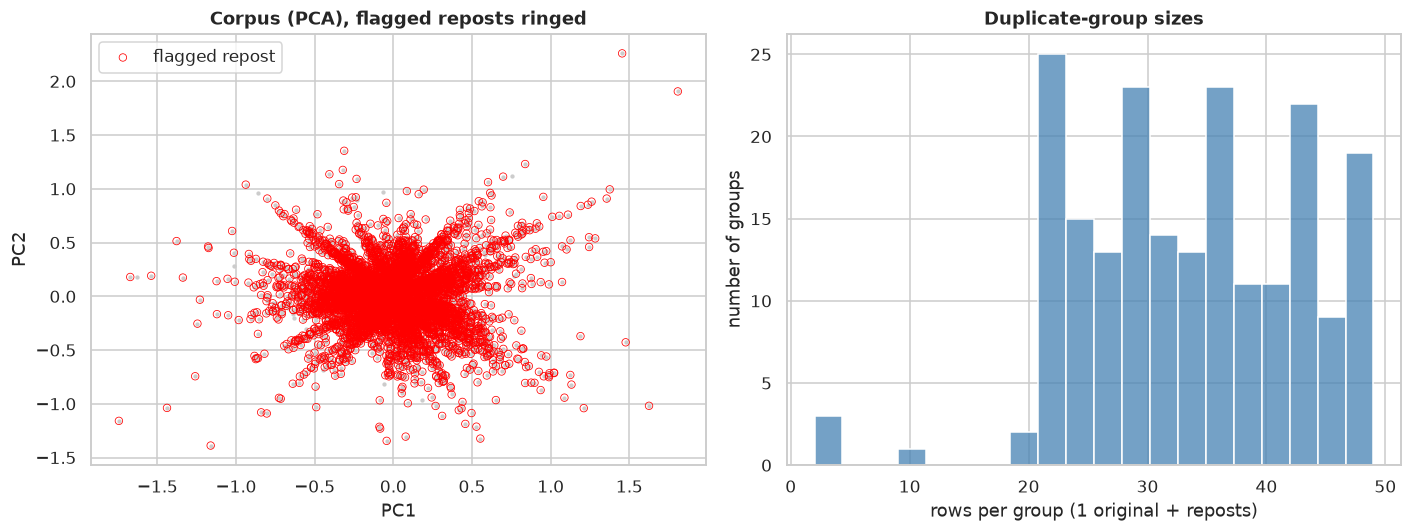

In [6]:
P = PCA(n_components=2, random_state=0).fit_transform(X)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(P[:, 0], P[:, 1], s=8, color="0.8", linewidth=0)
axes[0].scatter(P[drop, 0], P[drop, 1], facecolors="none", edgecolors="red", s=24, linewidths=0.5, label="flagged repost")
axes[0].legend()
axes[0].set(title="Corpus (PCA), flagged reposts ringed", xlabel="PC1", ylabel="PC2")

sizes = pd.Series([len(g) for g in groups])
sns.histplot(sizes, bins=20, ax=axes[1], color="steelblue")
axes[1].set(title="Duplicate-group sizes", xlabel="rows per group (1 original + reposts)", ylabel="number of groups")
plt.tight_layout()
plt.show()

## Notes — scope & scale

- **What works cleanly:** near-duplicates that form *tight, well-separated* microclusters — reposts,
  boilerplate, mirrored/templated content. `find_near_duplicates` groups rows by shared microcluster,
  so the duplicate spread must be well below the gap between distinct originals (raise `max_leaves`
  above your expected number of distinct items so each gets its own leaf).
- **Scale:** everything ran over the microclusters, not an `N × N` similarity matrix, and it streams —
  feed the corpus in chunks with `partial_fit` and memory stays bounded by `max_leaves`, so you can
  dedup a feed far larger than RAM.
- For exemplar selection (which representative to keep, or a diverse subset) see
  [`02_embeddings_and_inspection`](../02_embeddings_and_inspection.ipynb) and
  [`11_soft_assignment_coreset_diagnostics`](../11_soft_assignment_coreset_diagnostics.ipynb).